<u>דברים י</u>


כי הארץ אשר אתה בא־שמה לרשתה **לא כארץ מצרים** הוא אשר יצאתם משם אשר תזרע את־זרעך ו**השקית ברגלך** כגן הירק׃  
  
והשקית ברגלך. ארץ מצרים היתה צריכה להביא מים מנילוס, ברגלך, ולהשקותה – **צריך אתה לנדד משנתך** ולעמל, והנמוך שותה ולא הגבוה, ואתה מעלה המים מן הנמוך לגבוה, אבל זו למטר השמים תשתה מים – **אתה ישן על מטתך** ו'' משקה נמוך וגבוה גלוי ושאינו גלוי כאחת (ספרי):  (רש"י)
  
חורוד והמים הקבועים. איזהו חורוד הקבוע, כל ששהה שמונים יום. רבי חנינא בן אנטיגנוס אומר, בודקין אותו שלשה פעמים בתוך שמונים יום. ואלו הם מים הקבועים, **אכל לח ויבש של גשמים**, לח ויבש של **שלחים**. אכל היבש ואחר כך אכל הלח, **אינו מום**, עד שיאכל היבש אחר הלח: (משנה בכורות ו:ג)

$$
\varepsilon = 23.44^\circ \; [24.5^\circ,\; 22.1^\circ,\; 41\,\text{kyr}]
$$

$$
T = 2\pi \sqrt{\frac{a^3}{G\,(M_{\text{sun}} + M_{\text{earth}})}}
$$

- $T$ (time)
- $a$ (length)
- $G$ ($\mathrm{N\,m^2/kg^2}$)
- $M_{\text{sun}}$ (kg)
- $M_{\text{earth}}$ (kg)

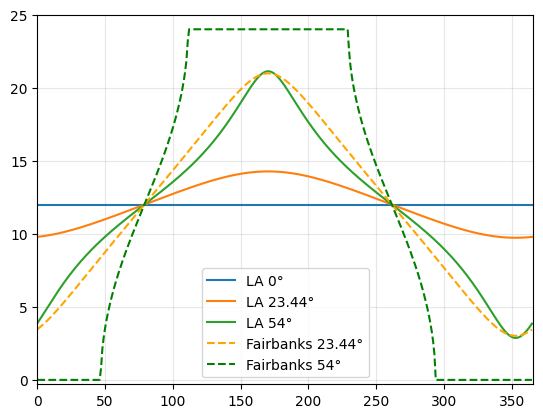

In [1]:
import numpy as np
import matplotlib.pyplot as plt

phi_LA = np.deg2rad(34.05)   # Los Angeles, CA
phi_FB = np.deg2rad(64.84)   # Fairbanks, AK
d = np.arange(0, 366)

# Tropical year length (days) for the solar declination cycle
Y = 365.2422

# Phase: set day 79 ~ March equinox (declination ~ 0)
d_eq = 79.0
lam = 2*np.pi * (d - d_eq) / Y  # Sun's ecliptic longitude

def day_length_hours(lat_rad, obliquity_deg, lam_rad):
    eps = np.deg2rad(obliquity_deg)
    delta = np.arcsin(np.sin(eps) * np.sin(lam_rad)) # declination
    x = -np.tan(lat_rad) * np.tan(delta)             # cos(H0) argument

    H0 = np.arccos(np.clip(x, -1.0, 1.0))

    polar_day = x <= -1.0
    polar_night = x >= 1.0

    L = (24.0 / np.pi) * H0
    L[polar_day] = 24.0
    L[polar_night] = 0.0
    return L

L0   = day_length_hours(phi_LA, 0.0,   lam)
L23  = day_length_hours(phi_LA, 23.44, lam)
L54  = day_length_hours(phi_LA, 54.0,  lam)
F23 = day_length_hours(phi_FB, 23.44, lam)
F54 = day_length_hours(phi_FB, 54.0, lam)

plt.figure()
plt.plot(d, L0,  label="LA 0°")
plt.plot(d, L23, label="LA 23.44°")
plt.plot(d, L54, label="LA 54°")
plt.plot(d, F23, "--", color="orange", label="Fairbanks 23.44°")
plt.plot(d, F54, "--", color="green", label="Fairbanks 54°")
plt.ylim(-0.3, 25)
plt.xlim(0,366)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


$$
[\ \text{Me}: 0.01^\circ,\ \text{Ve}: 177.4^\circ,\ \text{Ea}: 23.44^\circ,\ \text{Ma}: 25.19^\circ,\ \text{Ju}: 3.13^\circ,\ \text{Sa}: 26.73^\circ,\ \text{Ur}: 97.77^\circ,\ \text{Ne}: 28.32^\circ\ ]
$$